In [2]:
from IPython.display import Image

# Introduction
## Notations
- $k_\text{sub}$: number of sub-units in a receptor (typically 5)
- $n_\text{units}$: number of possibility/units or number of genes (typically 26)
- $\mathcal{U} = (u_1,u_2,\cdots u_{k_\text{sub}}) \in \mathbb{R}^{k_\text{sub}}\times \mathbb{R}^{n_\text{unit}}$: identity of a detector (homo-pentamers looks like (1,1,1,1,1)) where $u_i \in \mathbb{R}^{n_\text{unit}}$
- $r \in \mathbb{R}^{k_\text{sub}\times n_\text{unit}}$: index / identity of a receptor. Compation of the $\mathcal{U}$
- $\ell \in \mathbb{N}^{L}$: index / identity of a ligand
- $\mathcal{F}$ : ensemble of families of ligand
- $f$ : one specific family of ligand
- $\alpha \in [\text{o}, \text{c}]$: index for open/close or leakiness sometimes.
- $K_\alpha^{(r,\ell)}$: dissociation constant of the channel in the $\alpha$ state, between a receptor $r$ and a ligand $\ell$
- $\Delta E_\alpha^{(r,\ell)} = E_\alpha^{(r,\ell)}= E_\text{bound} - E_\text{unbound}$: energy difference between the bound and unbound state.
- $\epsilon_r = E_c - E_o$: energy difference between the closed and opened state of the channel without ligand. Leakiness $=e^\epsilon$
- $\theta = \{(\Delta E_\alpha^{(r,\ell)})_{\alpha,\ell}, \epsilon_r\}_r = \{\theta_r\}_r$ compact indexing for the characteristics of a channel
- $\bar{\Mu} = \{ \mu_\alpha^{(r,f)} \}_{r,f}$ and  $\bar{\Sigma} = \{ \sigma_\alpha^{(r,f)}\}_{r,f}$: respectively the matrix of the mean and std deviation of the distribution from which the energies are drawn for the receptor $r$ in response to the family of ligands $f$. <font color="red"> should the matrices depends on alpha, or should one be a shifted version of the other. In anyway the shift should be the same for every ligands, for a given receptor</font>
- $w$ generic name for $\mu_\alpha^{(r,f)}$ and $\sigma_\alpha^{(r,f)}$.
- $N$: total number of receptors in the array.
- $\mathcal{A} = (a_0,a_1, \cdots , a_N)$: activity value of the array of receptors.

---
## Single receptor characteristics : The Physical Model of a Receptor

We start by describing the physical model of a single receptor. Using the MWC model of ion channel.
Each receptor is made of $k_\text{sub}$ sub-units among $n_\text{unit}$ possible units.
We denote $\bm{r} = (r_0 \cdots r_{k_\text{sub}}) \in \mathbb{R}^{n_\text{unit} \times k_\text{sub}}$ the identity of a receptor characterized by the identity of each of the units that composes it. 
The response of a receptor $\bm{r}$ to a ligand $\ell$ at concentration $c$ can be written using the MWC model for ion channel opening:
$$
p_o^r(c,\ell) = \frac{\prod_{u\in \mathcal{U}} (1+c/K_o^{(u,\ell)})}{\prod_{u\in \mathcal{U}} (1+c/K_o^{(u,\ell)}) + e^{-\epsilon}\prod_{u\in \mathcal{U}}(1+c/K_c^{(u,\ell)})}
$$
Where the $K$'s are called the affinities and defined by:
$$
K_o^{(u,\ell)} = \exp\left[ \Delta E_o^{u,\ell} \right]
$$
$$
K_c^{(u,\ell)} = \exp\left[ \Delta E_c^{u,\ell} \right]
$$

In the rest of the document, we drop the $\Delta$.

Each affinity correspond to the response of a sub-unit to a given ligand. In the next section, we describe how to generate ligands from a given environment

---
## Generating Ligand/Unit interactions : The Environment
We assume that the receptor array is designed for sensing a large number of ligand. Any ligand is defined by 

1. its interaction with every units: $\{E_\alpha^{u,\ell}\}_{\alpha,u}$
2. A probability distribution of concentration: $p_\ell(c)$

To model the random encounter of a ligand, we categorize them into families. All the ligands of a given familly is assumed to have similar properties. As a consequence, the random encounter of a ligand of a given familly lies within a fairly narrow distribution (Normal) specific to each sub-unit.
For a given familly $f$:
$$
P_\alpha^{u,f}( E) = P(E | \alpha,u,f) = \mathcal{N}(\mu_\alpha^{u,f},\sigma_\alpha^{u,f})
$$
Where $\alpha \in \{ o, c\}$. The goal is to optimize the mean and standard deviation of the probability distribution of each individual sub-unit to each familly, in order to maximize the mutual information between a ligand's identity and/or its concentration in a given environment.

In total, the number of parameters to optimize for a single receptor is:
$$
N_\text{param} = \underbrace{n_\text{unit}}_\text{\# of different units} \times ( \underbrace{\underbrace{2}_{\mu,\sigma} \times \underbrace{2}_\text{o,c} \times \underbrace{N_\mathcal{F}}_\text{\# of families}}_{interaction} + \underbrace{n_\epsilon}_ \text{\# parameter for $\epsilon$}) + \underbrace{N_\mathcal{F}\times n_c}_\text{\# parameter for the concentration}
$$


---

## Array of receptors


We now consider an array of $N$ receptors, and write the activity of this array as $\mathcal{A} = (a_0,a_1, \cdots , a_N)$. We compute the mutual information between the activity of the array and ligand's identity and concentration:
$$
I(\mathcal{A};(c,\ell)) = H(\mathcal{A}) - H(\mathcal{A} | (c,\ell)),
$$
We consider the mapping between affinities, and activity as deterministic, noiseless: $H(A | (c,\ell)) = 0$.
Thus we want to maximize $H(\mathcal{A}) = \sum p(\mathcal{A}) \log[p(\mathcal{A})]$.

### Single receptor computation

let us first compute the density probability of activation for an array made of a single receptor:
$$
\begin{aligned}
p(a) &= \underbrace{\int_{E_c^0} \text{d}E_c^0 \cdots \int_{E_c^{n_\text{units}}} \text{d}E_c^{n_\text{unit}} \int_{E_o^0} \text{d}E_o^0 \cdots \int_{E_o^{n_\text{unit}}} \text{d}E_o^{n_\text{unit}} \text{d}\epsilon p(E_c^0)\cdots p(E_c^{n_\text{units}}) p(E_o^0)\cdots p(E_o^{n_\text{units}})}_{\prod_\alpha \prod_{u\in\mathcal{U}} \int_{E_\alpha^u} \text{d}E_\alpha^u p(E_\alpha^u)} \int_\epsilon p(\epsilon) p(a | E_c^0 , \cdots , E_c^{n_\text{units}}, E_o^0 \cdots E_o^{n_\text{units}}, \epsilon).\\
& = \prod_\alpha \prod_{u\in\mathcal{U}} \int_{E_\alpha^u} \text{d}E_\alpha^u p(E_\alpha^u) \int_\epsilon \text{d}\epsilon p(a | \{ E_\alpha^u\}_{\alpha,u},\epsilon)
\end{aligned}
$$
Where we can write the probability that the affinity energy of given sub-unit in the state $\alpha$ is the sum over the probability over each family:
$$
p(E_\alpha^{u}) = p(E | \alpha, u) = \sum_{f\in\mathcal{F}} p(E | \alpha, u, f) p(f)
$$

Combining the two, we got :

$$
\prod_\alpha \prod_{u\in\mathcal{U}} \int_{E_\alpha^u} \text{d}E_\alpha^u \sum_{f\in\mathcal{F}} p(E | \alpha, u, f) p(f) \int_\epsilon \text{d}\epsilon p(a | \{ E_\alpha^u\}_{\alpha,u},\epsilon)
$$

To compute the probability of observing a specific activity values $\mathcal{A}$, we write:
$$
\begin{aligned}
p(\mathcal{A}) &=  \overbrace{\sum_{r\in\bm{r}}}^\text{sum over the receptors} \int_{\epsilon} p_r(\epsilon) \text{d}\epsilon \underbrace{\sum_{u\in\mathcal{U}(\bm{r})}}_\text{sum over sub-units}  \overbrace{\sum_{f\in\mathcal{F}}}^\text{sum over families} \prod_{\alpha =o,c} \int_{\Delta E^\alpha} \text{d}\Delta E^\alpha p_\alpha^{u,f}(\Delta E)  p(\mathcal{A} | \{\Delta E_r^c, \Delta E_r^o, \epsilon_r \}_r) \\
& = \sum_w \int \text{d}\theta p_w(\theta) p(\mathcal{A}|\{\theta_w\})
\end{aligned}
$$
where $w$ is the 

Where $\theta_\ell = (\Delta E_\ell^c, \Delta E_\ell^o, \epsilon_\ell)$.
There is a bijective mapping between the identity and the affinity curves: $\ell \leftrightarrow \theta_\ell$.
Now writing how this probability distribution vary with the mean or std deviation:
$$
\frac{\partial p(\mathcal{A})}{\partial w_\ell} = \int \text{d}\theta_\ell \left[ p(\mathcal{A} | \theta_\ell) \frac{\partial p(\theta_\ell)}{\partial w_\ell} + p(\theta_\ell) \frac{\partial p(\mathcal{A} | \theta_\ell)}{\partial \theta_\ell} \right]
$$
where $w_i$ could be $\mu_\ell^\alpha$ or $\sigma_\ell^\alpha$, and $\alpha \in \{o,c\}$.
The first term, is easy to compute because $p(\theta_i)$ is just a normal distribution, so it's easy to compute how it varies with the mean and std deviation.
Concerning the second term, we can write $\mathcal{A} = F(c,\theta)$, where $F = (p_o^{(1)}, p_o^{(2)},\cdots,p_o^{(N)})$.
Therefore, we can write the probability as:
$$
p(\mathcal{A}|\theta) = \frac{p(c)}{\|F'(c,\theta)\|},
$$
as a result, we can write its derivative:
$$
\frac{\partial p(\mathcal{A}|\theta)}{\partial \theta_i} = - p(c) \frac{\partial }{\partial \theta_i}\left[ \frac{1}{\|F'(c,\theta)\|} \right]
$$
$$
\frac{\partial H(\mathcal{A})}{\partial w} = \frac{\partial}{\partial w}\left\{ E\left[ \ln\left[\int d\theta \frac{p(\theta)}{F'(c,\theta)} \right] \right] \right\}. 
$$


##### Appendice concerning the change of variable:


### 1. The Geometric Interpretation
Since $c$ is a scalar, the vector $\mathcal{A} = F(c)$ traces out a **1D curve (a manifold)** inside the $N$-dimensional space.

Consequently, the probability distribution $P(A)$ is **singular**. This means the probability density is zero everywhere in the $N$-dimensional space *except* along that specific curve defined by $F(c)$.

### 2. The Formula (Density on the Curve)
If you define the probability density of $A$ with respect to the **arc length** (or line measure) along the curve, you can use the principle of conservation of probability mass:

$$P(c) |dc| = P(A) dL$$

Where $dL$ is the differential length element along the curve in the $N$-dimensional space. The relationship between $dL$ and $dc$ is determined by the magnitude of the derivative vector (the speed of the curve).

**The Formula:**
$$P(A) = \frac{P(c)}{\| F'(c) \|}$$

Where:
* $P(A)$ is the density at the point $A = F(c)$ on the curve.
* $F'(c)$ is the derivative vector $\left( \frac{df_1}{dc}, \frac{df_2}{dc}, \dots, \frac{df_N}{dc} \right)$.
* $\| F'(c) \|$ is the Euclidean norm (length) of that derivative vector:
    $$\| F'(c) \| = \sqrt{ \sum_{i=1}^{N} \left( \frac{df_i(c)}{dc} \right)^2 }$$

---

### 3. The Dirac Delta Formulation (Density in $\mathbb{R}^N$)
If you need to express $P(A)$ as a formal density over the entire space $\mathbb{R}^N$ (for example, to use in an integral over the whole space), you must use the **Dirac delta function**.

$$P(\mathbf{x}) = \int_{-\infty}^{\infty} P(c) \, \delta^{(N)}(\mathbf{x} - F(c)) \, dc$$

Where:
* $\mathbf{x}$ is a generic vector in $\mathbb{R}^N$.
* $\delta^{(N)}$ is the $N$-dimensional Dirac delta function.

This formula essentially says: "The probability is entirely concentrated on the curve defined by $F(c)$, weighted by the original probability $P(c)$."

## Effective infomax algo

Instead of directly optimizing the whole array, we will perform an approximate infomax algorithm that consists in optimizing each receptors individually, while forcing them to be as different (uncorrelated as possible).
$$H(\mathcal{A}) = \underbrace{\sum_{i=1}^N H(a_i)}_{\text{Maximize Individual Info}} - \underbrace{\mathcal{T}(a_1, \dots, a_N)}_{\text{Minimize Redundancy}}$$
Where $\mathcal{T}$ is the **Total Correlation** (or Multi-information).

$$L = -\sum_{i=1}^N H(a_i) + \lambda \sum_{i \neq j} \text{Cov}(a_i, a_j)^2$$

Let us optimize the individual entropy:


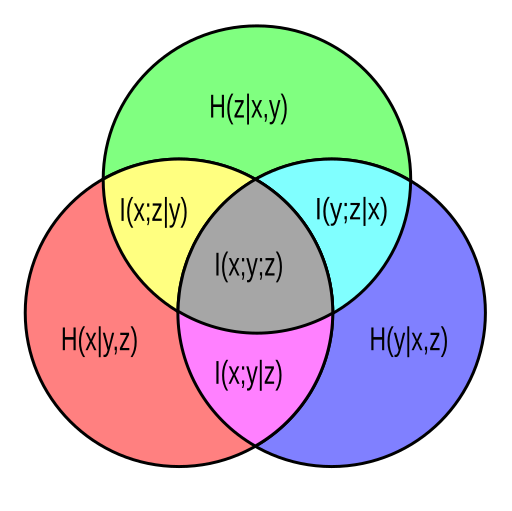

In [3]:

Image('VennInfo3Var.png', width=300)